In [42]:
import pandas as pd
import numpy as np
import random

# 导入数据
dataset = pd.read_csv(r"D:\graduation thesis\DataSet\newHouse\national  - 副本.csv")
dataset=dataset[~dataset['rand'].isin([1])]

# 输出数据预览
#print(dataset.head())

# 准备训练数据
# 自变量：室、厅、面积（平米）、朝向、装修、所在高度、总楼层高	height、建筑结构、关注人数、发布时长（天）、所在地区、城市绿化率(%)、单价、税收优惠
# 交通方便（或近地铁）、近商圈、海景河景湖景、车位 、采光好、近公园、市辖区城镇常驻人口(万人)、建成区面积(平方公里)、水资源总量(万立方米)
# 因变量：单位房价
X = dataset.iloc[:, 0:23].values
y = dataset.iloc[:, 23].values

#dataset.to_csv(r"D:\graduation thesis\DataSet\newHouse\national  - 副本2.csv")


In [43]:
path=r"D:\graduation thesis\DataSet\newHouse\national  - 副本.csv"
df=pd.read_csv(path)
df=df[~df['rand'].isin([1])]

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 493 entries, 0 to 492
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gdp                            493 non-null    float64
 1   region                         493 non-null    int64  
 2   green_rate                     493 non-null    float64
 3   c_population                   493 non-null    float64
 4   c_area                         493 non-null    float64
 5   c_water_resources              493 non-null    int64  
 6   min_frame_area                 493 non-null    int64  
 7   max_frame_area                 493 non-null    int64  
 8   biz                            493 non-null    int64  
 9   decoration                     493 non-null    int64  
 10  longitude                      493 non-null    float64
 11  latitude                       493 non-null    float64
 12  min_frame_rooms                493 non-null    int

In [45]:
print(df['reference_unit_price'].describe())

count       493.000000
mean      16650.827586
std       12280.112128
min        4500.000000
25%        9000.000000
50%       13000.000000
75%       20000.000000
max      112800.000000
Name: reference_unit_price, dtype: float64


d:\anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='reference_unit_price', ylabel='Density'>

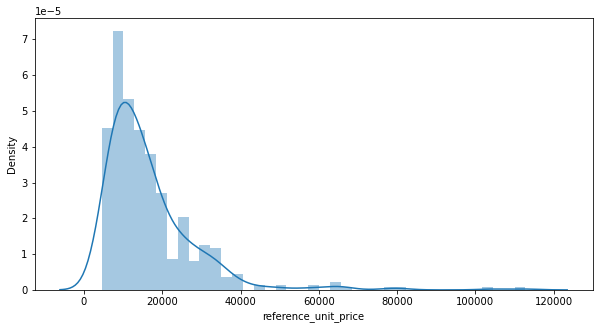

In [46]:
#导入类库和加载数据集
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#观察price的数据分布
plt.figure(figsize = (10,5))
# plt.xlabel('price')
sns.distplot(df['reference_unit_price'])

In [8]:
#自变量与因变量的相关性分析
plt.figure(figsize = (20,10))
internal_chars = ['park', 'light','p_lot','water','business','transport','l_tax','hall','room','area','orientation','furnishment','level','height','architecture','follower','span','gdp','region','green_rate','c_population','c_area','c_water_resources','t_price']
corrmat = df[internal_chars].corr()  # 计算相关系数
sns.heatmap(corrmat, square=False, linewidths=.5, annot=True) #热力图

KeyError: "['park', 'light', 'p_lot', 'water', 'business', 'transport', 'l_tax', 'hall', 'room', 'area', 'orientation', 'furnishment', 'level', 'height', 'architecture', 'follower', 'span', 't_price'] not in index"

<Figure size 1440x720 with 0 Axes>

<AxesSubplot:>

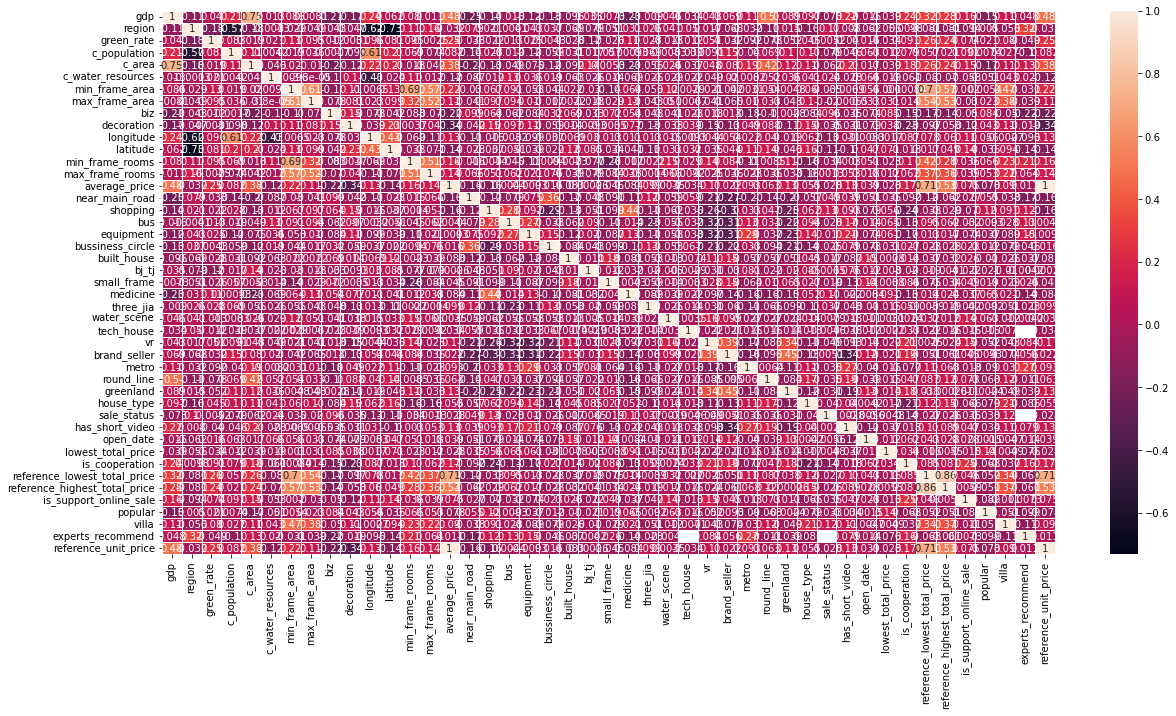

In [36]:
#自变量与因变量的相关性分析
plt.figure(figsize = (20,10))
internal_chars = ['gdp', 'region', 'green_rate', 'c_population', 'c_area', 'c_water_resources', 'min_frame_area', 'max_frame_area', 'biz', 'decoration', 'longitude', 'latitude', 'min_frame_rooms', 'max_frame_rooms', 'average_price', 'near_main_road', 'shopping', 'bus', 'equipment', 'bussiness_circle', 'built_house', 'bj_tj', 'small_frame', 'medicine', 'three_jia', 'water_scene', 'tech_house', 'vr', 'brand_seller', 'metro', 'round_line', 'greenland', 'house_type', 'sale_status', 'has_short_video', 'open_date', 'lowest_total_price', 'is_cooperation', 'reference_lowest_total_price', 'reference_highest_total_price', 'is_support_online_sale', 'popular', 'villa', 'experts_recommend', 'reference_unit_price']
corrmat = df[internal_chars].corr()  # 计算相关系数
sns.heatmap(corrmat, square=False, linewidths=.5, annot=True) #热力图

In [47]:
print(corrmat["reference_unit_price"].sort_values(ascending=False))

reference_unit_price             1.000000
average_price                    1.000000
reference_lowest_total_price     0.710379
reference_highest_total_price    0.528476
gdp                              0.482587
c_area                           0.380307
green_rate                       0.248363
min_frame_area                   0.221780
is_cooperation                   0.173069
min_frame_rooms                  0.158248
max_frame_rooms                  0.138171
greenland                        0.130609
longitude                        0.126562
has_short_video                  0.125785
max_frame_area                   0.107743
vr                               0.104478
three_jia                        0.098806
metro                            0.092815
villa                            0.090331
c_population                     0.081931
is_support_online_sale           0.075337
round_line                       0.063433
house_type                       0.054893
open_date                        0

In [48]:
#特征缩放
data = df.astype('float')
x = data.drop('reference_unit_price',axis=1)
y = data['reference_unit_price']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
newX= scaler.fit_transform(x)
newX = pd.DataFrame(newX, columns=x.columns)
newX.head()

,gdp,region,green_rate,c_population,c_area,c_water_resources,min_frame_area,max_frame_area,biz,decoration,...,open_date,lowest_total_price,is_cooperation,reference_lowest_total_price,reference_highest_total_price,is_support_online_sale,popular,villa,experts_recommend,rand
0,0.068613,0.2,0.600316,0.26524,0.124542,0.037169,0.119522,0.031417,1.0,1.0,...,0.010785,0.000098,1.0,0.021112,0.013458,1.0,0.0,0.0,0.0,0.283253
1,0.068613,0.2,0.600316,0.26524,0.124542,0.037169,0.111554,0.028204,1.0,0.0,...,0.008156,0.000065,1.0,0.025232,0.008896,1.0,0.0,0.0,0.0,0.441403
2,0.068613,0.2,0.600316,0.26524,0.124542,0.037169,0.109562,0.028918,1.0,1.0,...,0.017181,0.000059,1.0,0.019567,0.007527,0.0,0.0,0.0,0.0,0.142844
3,0.068613,0.2,0.600316,0.26524,0.124542,0.037169,0.123506,0.037487,1.0,1.0,...,0.017827,0.000071,1.0,0.022657,0.012546,0.0,1.0,0.0,0.0,0.987918
4,0.068613,0.2,0.600316,0.26524,0.124542,0.037169,0.151394,0.030346,1.0,1.0,...,0.027743,0.000136,0.0,0.047374,0.015055,0.0,0.0,0.0,0.0,0.492666


In [49]:
#先将数据集分成训练集和测试集
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(newX, y, test_size=0.2, random_state=43)
X_train,X_test,y_train,y_test 

(          gdp  region  green_rate  c_population    c_area  c_water_resources  \
 431  0.232845     0.6    0.438389      0.129167  0.487179           0.000000   
 237  0.137613     0.4    0.526066      1.000000  0.191209           0.115983   
 178  0.024235     0.2    0.475513      0.265240  0.014652           0.037169   
 444  0.186228     0.4    0.254344      1.000000  0.261538           0.115983   
 18   0.930534     0.2    1.000000      0.265240  1.000000           0.037169   
 ..        ...     ...         ...           ...       ...                ...   
 277  0.028104     1.0    0.221169      0.000000  0.122344           0.011684   
 305  1.000000     0.4    0.080569      1.000000  0.880586           0.115983   
 255  0.247371     0.4    0.561611      1.000000  0.153846           0.115983   
 320  0.141027     0.4    0.617694      1.000000  0.159707           0.115983   
 324  0.280081     1.0    0.410742      0.000000  0.443223           0.011684   
 
      min_frame_area  max_

In [50]:
#模型建立
from sklearn import metrics
def RF(X_train, X_test, y_train, y_test):    #随机森林 
    from sklearn.ensemble import RandomForestRegressor
    model= RandomForestRegressor(n_estimators=200,max_features=None)
    model.fit(X_train, y_train)
    predicted= model.predict(X_test)
    mse = metrics.mean_squared_error(y_test,predicted)
    return (mse/10000)

def LR(X_train, X_test, y_train, y_test):    #线性回归
    from sklearn.linear_model import LinearRegression            
    LR = LinearRegression()
    LR.fit(X_train, y_train)
    predicted = LR.predict(X_test)
    mse = metrics.mean_squared_error(y_test,predicted)
    return (mse/10000)

In [51]:
print('RF mse: ',RF(X_train, X_test, y_train, y_test))
print('LR mse: ',LR(X_train, X_test, y_train, y_test))

RF mse:  840.3595736260102
LR mse:  8.498570588405924e-26


In [26]:
import sklearn.datasets as datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

# 导入数据，路径中要么用\\或/或者在路径前加r
dataset = pd.read_csv(r'D:\graduation thesis\DataSet\合并二手房.csv')

# 输出数据预览
print(dataset.head())

# 准备训练数据
# 自变量：室、厅、面积（平米）、朝向、装修、所在高度、总楼层高	height、建筑结构、关注人数、发布时长（天）、所在地区、城市绿化率(%)、单价、税收优惠
# 交通方便（或近地铁）、近商圈、海景河景湖景、车位 、采光好、近公园、市辖区城镇常驻人口(万人)、建成区面积(平方公里)、水资源总量(万立方米)
# 因变量：单位房价
X = dataset.iloc[:, 0:23].values
y = dataset.iloc[:, 23].values

# 将数据分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0)
regr = RandomForestRegressor()
# regr = RandomForestRegressor(random_state=100,
#                              bootstrap=True,
#                              max_depth=2,
#                              max_features=2,
#                              min_samples_leaf=3,
#                              min_samples_split=5,
#                              n_estimators=3)
pipe = Pipeline([('scaler', StandardScaler()), ('reduce_dim', PCA()),
                 ('regressor', regr)])
pipe.fit(X_train, y_train)
ypipe = pipe.predict(X_test)

   park  light  p_lot  water  business  transport  l_tax  hall  room    area  \
0     0      0      0      0         0          0      1     2     1   75.01   
1     0      0      0      1         0          0      1     2     2  115.39   
2     0      0      0      0         0          0      0     2     2  101.80   
3     0      0      0      0         0          0      1     2     1   65.25   
4     0      0      0      0         0          0      0     3     2   83.23   

   ...  architecture  follower  span     gdp  region  green_rate  \
0  ...             2       175   365  835.37       5       42.34   
1  ...             2       437   365  835.37       5       42.34   
2  ...             2         2   180  835.37       5       42.34   
3  ...             3       169   365  835.37       5       42.34   
4  ...             2        14   240  835.37       5       42.34   

   c_population  c_area  c_water_resources  t_price  
0          73.0    52.0             158392    137.0  
1 

[0.036284998939678965, 0.3259186485184082, 0.06884159119164689, 0.022764720644373508, 0.03486434154304085, 0.019832898721674614, 0.014373176147891747, 0.05106139668127148, 0.014590249202174678, 0.013867306957624642, 0.021036630559991564, 0.015015195289498453, 0.020532309107023618, 0.01728281773599938, 0.020934466474621813, 0.019341716362564473, 0.029993225388368103, 0.03442635175740013, 0.030184191659307864, 0.01911769411173821, 0.03482596804695972, 0.047367528831807386, 0.0875425761269335]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


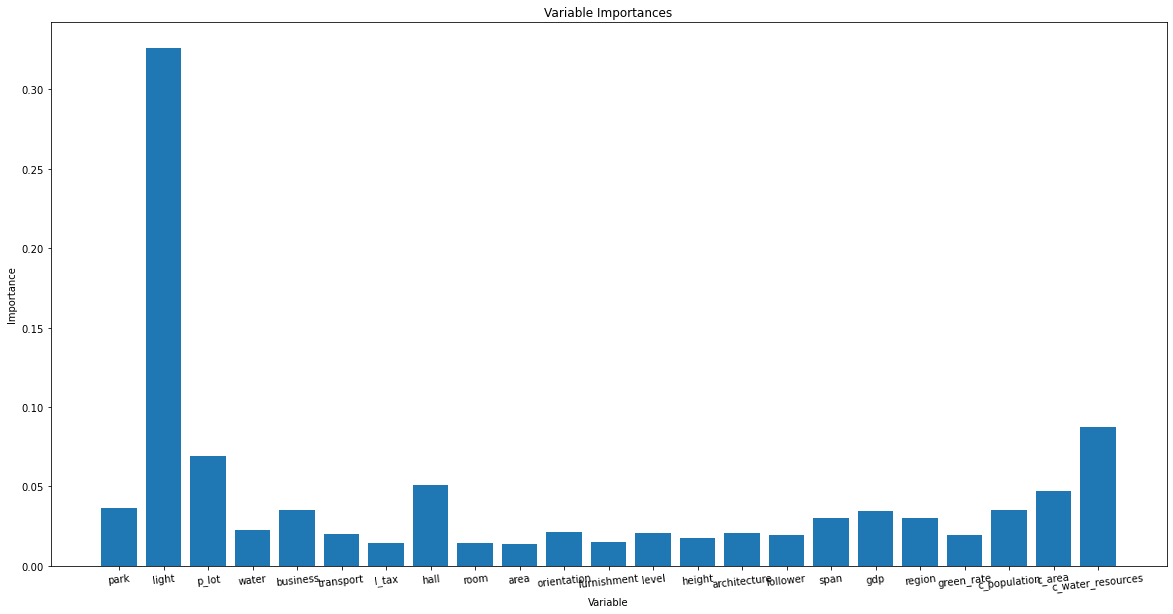

In [32]:
# Get numerical feature importances
importances = list(regr.feature_importances_)
# List of tuples with variable and importance
print(importances)

# Saving feature names for later use
feature_list = list(dataset.columns)[0:23]

feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
# Print out the feature and importances 
# [print('Variable: {:20} Importance: {}'.format(*pair)) for pair in feature_importances];

# Import matplotlib for plotting and use magic command for Jupyter Notebooks

import matplotlib.pyplot as plt
# Set the style
# plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(importances)))
print(x_values)
plt.figure(figsize = (20,10))
# Make a bar chart
plt.bar(x_values, importances, orientation = 'vertical')
# Tick labels for x axis
plt.xticks(x_values, feature_list,rotation=6)
# Axis labels and title
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.show()

In [3]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

X_new = SelectKBest(chi2, k=2).fit_transform(X, y)
X_new.shape


MemoryError: Unable to allocate 74.6 GiB for an array with shape (267305, 37451) and data type int64

In [5]:
# 将数据分为训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0)
                                                    

In [6]:
# 特征缩放
# 因为数据单位，自变量数值范围差距巨大，不缩放也没问题
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [52]:
# 训练随机森林解决回归问题
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=200, random_state=0)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [53]:
# 评估回归性能
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:',
      np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 524.0026262626263
Mean Squared Error: 8575831.915429292
Root Mean Squared Error: 2928.4521364415864


In [ ]:
import sklearn.datasets as datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

# 导入数据，路径中要么用\\或/或者在路径前加r
dataset = pd.read_csv(r'C:\Users\ASUS\Desktop\graduation thesis\DataSet\合并二手房.csv')

# 输出数据预览
print(dataset.head())

# 准备训练数据
# 自变量：室、厅、面积（平米）、朝向、装修、所在高度、总楼层高	height、建筑结构、关注人数、发布时长（天）、所在地区、城市绿化率(%)、单价、税收优惠
# 交通方便（或近地铁）、近商圈、海景河景湖景、车位 、采光好、近公园、市辖区城镇常驻人口(万人)、建成区面积(平方公里)、水资源总量(万立方米)
# 因变量：单位房价
X = dataset.iloc[:, 0:23].values
y = dataset.iloc[:, 23].values

# 将数据分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0)
regr = RandomForestRegressor()
# regr = RandomForestRegressor(random_state=100,
#                              bootstrap=True,
#                              max_depth=2,
#                              max_features=2,
#                              min_samples_leaf=3,
#                              min_samples_split=5,
#                              n_estimators=3)
pipe = Pipeline([('scaler', StandardScaler()), ('reduce_dim', PCA()),
                 ('regressor', regr)])
pipe.fit(X_train, y_train)
ypipe = pipe.predict(X_test)

from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
import os

# 执行一次
# os.environ['PATH'] = os.environ['PATH']+';'+r"D:\CLibrary\Graphviz2.44.1\bin\graphviz"
dot_data = StringIO()
export_graphviz(pipe.named_steps['regressor'].estimators_[0],
                out_file=dot_data)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png(r'C:\Users\ASUS\Desktop\graduation thesis\runProcess\randomTree.png')
Image(graph.create_png())

In [ ]:
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_jpg(r'C:\Users\ASUS\Desktop\graduation thesis\runProcess\randomTree.jpg')
Image(graph.create_jpg())

In [6]:
print(dot_data.getvalue)

<built-in method getvalue of _io.StringIO object at 0x000001A498041AF8>


In [7]:
print(graph.create)

<bound method Dot.create of <pydotplus.graphviz.Dot object at 0x000001A9D6CA16C8>>


In [54]:
# 评估回归性能
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, ypipe))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, ypipe))
print('Root Mean Squared Error:',
      np.sqrt(metrics.mean_squared_error(y_test, ypipe)))

NameError: name 'ypipe' is not defined